# ISFS Multi-Subject Analysis


## 1. Imports

In [1]:
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import yasa

from infraslow.io.psg_loader import BioserenityPSGLoader
from infraslow.io.usleep_hypnodensity import (
    make_usleep_annotation_loader,
    hypnodensity_probs_at_times,
)
from infraslow.processing.utils import find_stage_bouts
from infraslow.processing.spindle import spindles_detect, DEFAULT_STAGE_MAP
from infraslow.processing.infraslow import (
    eeg_envelope,
    infraslow_spectrum,
    relative_power,
    baseline_correct,
    bigaussian,
    fit_isfs,
    chromatogram_peak_area,
    isfs_lowpass,
    isfs_phase_bins,
    isfs_event_phase_distribution,
)
from infraslow.pipeline.phase import bin_center_angle, build_subject_continuous_phase_timeseries

plt.rcParams["figure.dpi"] = 110
PURPLE, LPURPLE, GOLD = "#5b2a86", "#c9b3e6", "#f2c14e"

logging.basicConfig(
    level=logging.WARNING,  # INFO would print once per subject; too noisy for a cohort run
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)


## 2. User Configuration

In [2]:
# --- Cohort subjects
SUBJECT_IDS = [
    "318517", "318562", 
    "318619", "318658", "318661",
    "318667", "318668", "318679", "318709",
]

EDF_DIR = "$OAK/psg/Bioserenity/edf"
USLEEP_HYPNODENSITY_DIR = "$OAK/psg/Bioserenity/USleep"

# channel name
CHANNEL = "C3"

# --- Sampling rates (Hz) ---
EEG_SFREQ = 200.0
HYPNODENSITY_SFREQ = 1.0

# --- Epoching ---
EPOCH_SEC = 3.0

# --- Frequency bands (Hz) ---
SIGMA_BAND = (11.0, 16.0)
INFRASLOW_BAND = (0.01, 0.1)
BASELINE_BAND = (0.06, 0.1)
WINDOW_SEC = 100.0

# --- N2 bout / ISFS-cycle definitions ---
MIN_N2_BOUT_SEC = 200.0
ISFS_PERIOD_SEC = (25.0, 100.0)

# --- Phase binning ---
N_PHASE_BINS = 8
N_PHASE_POINTS = 8 

USLEEP_STAGE_ORDER = ("Wake", "N1", "N2", "N3", "REM")

bin_ids = np.arange(1, N_PHASE_BINS + 1)
bin_centers = bin_center_angle(bin_ids)


## 4. Per-Subject Processing

In [3]:
def process_subject(subject_id: str, channel: str) -> dict:
    # --- Section 1: Load EEG ---
    psg_loader = BioserenityPSGLoader(
        edf_dir=EDF_DIR,
        subject_id=subject_id, sf=EEG_SFREQ, requested_channels=[channel],
        annotation_loader=make_usleep_annotation_loader(
            channel, base_dir=USLEEP_HYPNODENSITY_DIR, epoch_sec=EPOCH_SEC, src_epoch_sec=HYPNODENSITY_SFREQ,
            stage_order=USLEEP_STAGE_ORDER,
        ),
    ).load()
    if channel not in psg_loader.resolved_channels:
        raise RuntimeError(f"channel {channel!r} not resolved (missing: {psg_loader.missing_channels})")

    eeg = np.asarray(psg_loader.get_channel(channel), dtype=float)
    sf = float(psg_loader.sf)
    eeg_duration_sec = len(eeg) / sf
    t_epoch = psg_loader.annotations["t"].to_numpy()
    hypnodensity_3s = psg_loader.annotations[list(USLEEP_STAGE_ORDER)].to_numpy()
    hypnogram_3s = psg_loader.annotations["stage"].to_numpy()

    # --- Section 2: Detect spindles ---
    spindles = spindles_detect(psg_loader, ch_names=channel, include=(2,), epoch_sec=EPOCH_SEC)
    if spindles is None:
        raise RuntimeError("no spindles detected")
    spindle_summary = spindles.summary()
    n_spindles = len(spindle_summary)
    peak_times = spindle_summary["Peak"].to_numpy()

    mean_spindle_duration_sec = spindle_summary["Duration"].mean()
    mean_spindle_amplitude_uv = spindle_summary["Amplitude"].mean()
    mean_spindle_frequency_hz = spindle_summary["Frequency"].mean()
    mean_spindle_power = spindle_summary["AbsPower"].mean()

    # --- Section 3: N2 bout detection ---
    hypnogram_int_3s = np.array([DEFAULT_STAGE_MAP[s.lower()] for s in hypnogram_3s])
    n2_bouts = np.asarray(
        find_stage_bouts(hypnogram_int_3s, stage_codes=(2,), epoch_sec=EPOCH_SEC, min_dur=MIN_N2_BOUT_SEC)
    ).reshape(-1, 2)
    if n2_bouts.size == 0:
        raise RuntimeError(f"no N2 bouts >= {MIN_N2_BOUT_SEC:g}s")
    bout_durations_sec = n2_bouts[:, 1] - n2_bouts[:, 0]
    n2_bout_total_sec = float(bout_durations_sec.sum())

    def _times_in_any_bout(times, bouts):
        times = np.asarray(times, dtype=float)
        starts, stops = bouts[:, 0], bouts[:, 1]
        idx = np.clip(np.searchsorted(starts, times, side="right") - 1, 0, len(starts) - 1)
        return (times >= starts[idx]) & (times < stops[idx])

    n_spindles_in_n2_bouts = int(_times_in_any_bout(peak_times, n2_bouts).sum())
    n2_bout_spindle_rate = n_spindles_in_n2_bouts / (n2_bout_total_sec / 60.0) if n2_bout_total_sec > 0 else np.nan

    def _bout_has_spindle(a, b):
        return bool(np.any((peak_times >= a) & (peak_times < b)))

    n2_bouts_with_spindles = np.array([b for b in n2_bouts if _bout_has_spindle(*b)]).reshape(-1, 2)
    HAS_SPINDLE_BOUTS = len(n2_bouts_with_spindles) > 0

    # --- Section 4: Sigma envelope ---
    t_env, sigma_db = eeg_envelope(eeg, sf, band=SIGMA_BAND, sf_env=1.0, to_db=True, kind="power", wavelet=True)

    # --- Sections 5: Relative spectrum, baseline correction, bi-Gaussian fit ---
    FIT_OK = False
    fit = None
    freqs = corrected = None
    mu = isfs_peak_freq = isfs_peak_period_sec = amp = bandwidth = auc = isfs_chromatogram_area = np.nan
    detected = False
    if HAS_SPINDLE_BOUTS:
        freqs = None
        psd_list = []
        for a_b, b_b in n2_bouts_with_spindles:
            m0 = (t_env >= a_b) & (t_env < b_b)
            spec = infraslow_spectrum(sigma_db[m0], sf_env=1.0, window_sec=WINDOW_SEC)
            freqs = spec.freqs
            psd_list.append(spec.psd)
        mean_psd = np.vstack(psd_list).mean(axis=0)
        rel = relative_power(mean_psd, freqs, INFRASLOW_BAND)
        corrected = baseline_correct(rel, freqs, BASELINE_BAND)

        try:
            fit = fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND)
            FIT_OK = True
        except (RuntimeError, ValueError):
            fit = None

        if FIT_OK:
            amp, mu, sd_l, sd_r = fit["popt"]
            bandwidth, auc, detected = fit["bandwidth"], fit["auc"], fit["detected"]
            isfs_peak_freq = mu
            isfs_peak_period_sec = 1.0 / mu
            fg = np.linspace(*INFRASLOW_BAND, 400)
            chrom = chromatogram_peak_area(fg, bigaussian(fg, *fit["popt"]), threshold=fit["threshold"],
                                            infraslow_band=INFRASLOW_BAND)
            isfs_chromatogram_area = chrom["area"]

    # --- Section 6: ISFS filtering (whole night, once) ---
    isfs_filtered = isfs_lowpass(sigma_db, sf_env=1.0)

    # --- Section 7 prep: per-bout standardized phase bins + spindle times ---
    dist = None
    bouts_data = []
    if HAS_SPINDLE_BOUTS:
        for a_b, b_b in n2_bouts_with_spindles:
            m0 = (t_env >= a_b) & (t_env < b_b)
            tt_b = t_env[m0] - a_b
            filt_b = isfs_filtered[m0]
            std = filt_b.std()
            std_b = (filt_b - filt_b.mean()) / std if std > 0 else filt_b - filt_b.mean()
            bins_b, _ = isfs_phase_bins(tt_b, std_b, isfs_period=ISFS_PERIOD_SEC)
            pk_b = peak_times[(peak_times >= a_b) & (peak_times < b_b)] - a_b
            bouts_data.append((tt_b, bins_b, pk_b))
        dist = isfs_event_phase_distribution(bouts_data, min_events=5)
    preferred_bin = int(np.argmax(dist["pct"])) + 1 if dist is not None else np.nan

    # --- Section 8 prep: phase vs. stage probability ---
    phase_ts = build_subject_continuous_phase_timeseries(t_env, isfs_filtered, n2_bouts, isfs_period=ISFS_PERIOD_SEC)
    in_cycle = ~np.isnan(phase_ts["phase_angle"])
    mean_probs_per_point = np.full((N_PHASE_POINTS, len(USLEEP_STAGE_ORDER)), np.nan)
    if in_cycle.any():
        t_in = phase_ts["t"][in_cycle]
        phase_in = phase_ts["phase_angle"][in_cycle]
        probs_in = hypnodensity_probs_at_times(t_in, t_epoch, hypnodensity_3s)
        phase_edges = np.linspace(-np.pi, np.pi, N_PHASE_POINTS + 1)
        point_idx = np.digitize(phase_in, phase_edges[1:-1])
        for p in range(N_PHASE_POINTS):
            sel = point_idx == p
            if sel.any():
                mean_probs_per_point[p] = probs_in[sel].mean(axis=0)

    # --- Section 9: per-subject feature row ---
    summary = {
        "subject_id": subject_id,
        "channel": channel,
        "recording_duration_min": eeg_duration_sec / 60.0,
        "n2_total_duration_min": n2_bout_total_sec / 60.0,
        "n_n2_bouts": int(len(n2_bouts)),
        "n_spindles_total": int(n_spindles),
        "n2_spindle_rate_per_min": n2_bout_spindle_rate,
        "mean_spindle_duration_sec": mean_spindle_duration_sec,
        "mean_spindle_amplitude_uv": mean_spindle_amplitude_uv,
        "mean_spindle_frequency_hz": mean_spindle_frequency_hz,
        "mean_spindle_power_log10uv2": mean_spindle_power,
        "isfs_detected": bool(detected) if FIT_OK else False,
        "isfs_peak_freq_hz": isfs_peak_freq,
        "isfs_peak_period_sec": isfs_peak_period_sec,
        "isfs_amplitude": amp if FIT_OK else np.nan,
        "isfs_bandwidth_hz": bandwidth if FIT_OK else np.nan,
        "isfs_auc": auc if FIT_OK else np.nan,
        "isfs_chromatogram_peak_area": isfs_chromatogram_area if FIT_OK else np.nan,
        "preferred_spindle_phase_bin": preferred_bin,
    }

    return {
        "subject_id": subject_id,
        "FIT_OK": FIT_OK,
        "mu": mu,
        "popt": fit["popt"] if FIT_OK else None,
        "freqs": freqs,
        "corrected": corrected,
        "bouts_data": bouts_data,
        "dist": dist,
        "mean_probs_per_point": mean_probs_per_point,
        "summary": summary,
    }


## 5. Run Cohort

Processes each subject in `SUBJECT_IDS`, skipping (logging, not raising) any
that fails `process_subject`.


In [4]:
results = []
failed = []
for sid in SUBJECT_IDS:
    try:
        results.append(process_subject(sid, CHANNEL))
        print(f"[{len(results)}/{len(SUBJECT_IDS)}] OK: {sid}")
    except Exception as exc:
        failed.append((sid, str(exc)))
        print(f"SKIP {sid}: {exc}")

print(f"\nProcessed {len(results)}/{len(SUBJECT_IDS)} subjects ({len(failed)} skipped)")


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f509ff05db0> 



 uniquifying sao2 to sao2.1
___________________________________________________________________
Processing: 318517 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318517.edf
 duration 08.35.47, 30947s | time 21.42.18 - 06.18.05 | date 01.01.12

 signals: 26 (of 26) selected in an EDF+C file
  C3 | C4 | O1 | O2 | LEOG | REOG | ECGI | emg_CHIN
  emg_RLEG | emg_LLEG | THO | ABD | flow_PFLO | flow_TFLO | flow_CFLO | MICR
  imp | rr | LEAK | IPAP | EPAP | SAO2 | BODY | sao2.1
  HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
14:59:26 [WARNING] Hypnogram is SHORTER than data by 17.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


[1/9] OK: 318517
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f509ff05db0> 



___________________________________________________________________
Processing: 318562 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318562.edf
 duration 07.40.46, 27646s | time 21.51.51 - 05.32.37 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
14:59:46 [WARNING] Hypnogram is SHORTER than data by 16.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


[2/9] OK: 318562
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f509ff05db0> 



...

[7/9] OK: 318668
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f509ff05db0> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

[8/9] OK: 318679
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f509ff05db0> 



___________________________________________________________________
Processing: 318709 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318709.edf
 duration 07.39.08, 27548s | time 22.03.25 - 05.42.33 | date 01.01.12

 signals: 28 (of 28) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | imp | rr | Leak | EPAP | IPAP
  Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
15:01:34 [WARNING] Hypnogram is SHORTER than data by 8.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


[9/9] OK: 318709

Processed 9/9 subjects (0 skipped)


## 6. Bi-Gaussian ISFS Fit (Group)

8/9 subjects have a successful bi-Gaussian ISFS fit


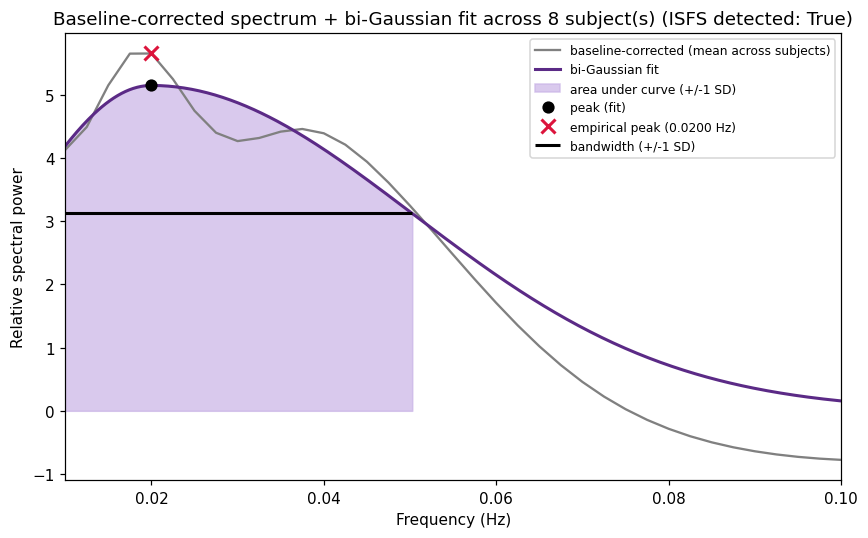

In [5]:
fit_results = [r for r in results if r["FIT_OK"]]
print(f"{len(fit_results)}/{len(results)} subjects have a successful bi-Gaussian ISFS fit")

if fit_results:
    freqs = fit_results[0]["freqs"]
    band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
    corrected = np.vstack([r["corrected"] for r in fit_results]).mean(axis=0)

    real_peak_idx = int(np.argmax(corrected[band_m]))
    real_peak_freq = float(freqs[band_m][real_peak_idx])

    try:
        fit = fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND)
        FIT_OK_GROUP = True
    except (RuntimeError, ValueError) as exc:
        fit = None
        FIT_OK_GROUP = False
        print(f"Bi-Gaussian fit on the mean spectrum failed ({exc}); skipping group plot.")

    if FIT_OK_GROUP:
        amp, mu, sd_l, sd_r = fit["popt"]
        lo, hi, bandwidth = fit["lo"], fit["hi"], fit["bandwidth"]
        auc, threshold, detected = fit["auc"], fit["threshold"], fit["detected"]

        fg = np.linspace(*INFRASLOW_BAND, 400)
        f_auc = np.linspace(lo, hi, 400)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(freqs[band_m], corrected[band_m], color="0.5", lw=1.5,
                label="baseline-corrected (mean across subjects)")
        ax.plot(fg, bigaussian(fg, *fit["popt"]), color=PURPLE, lw=2, label="bi-Gaussian fit")
        ax.fill_between(f_auc, bigaussian(f_auc, *fit["popt"]), color=LPURPLE, alpha=0.7,
                         label="area under curve (+/-1 SD)")
        ax.plot([mu], [bigaussian(mu, *fit["popt"])], "o", color="k", ms=7, zorder=5, label="peak (fit)")
        ax.plot([real_peak_freq], [corrected[band_m][real_peak_idx]], "x", color="crimson", ms=9,
                mew=2, zorder=6, label=f"empirical peak ({real_peak_freq:.4f} Hz)")
        ax.hlines(bigaussian(lo, *fit["popt"]), lo, hi, color="k", lw=2, label="bandwidth (+/-1 SD)")
        ax.set(xlim=INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
               title=f"Baseline-corrected spectrum + bi-Gaussian fit across {len(fit_results)} "
                     f"subject(s) (ISFS detected: {detected})")
        ax.legend(fontsize=8)
        fig.tight_layout()
else:
    print("No subject had a successful bi-Gaussian fit -- skipping group plot.")


## 7. ISFS Peak Distribution (Group)

Peak frequency across subjects: mean=0.0278 Hz, median=0.0238 Hz, SD=0.0128 Hz, n=8


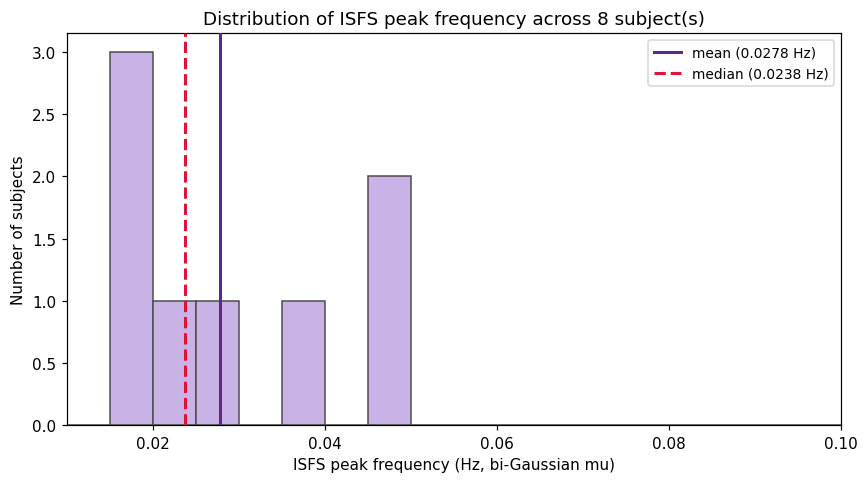

In [6]:
mus = np.array([r["mu"] for r in fit_results])
if mus.size:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bin_w = 0.005
    bins = np.arange(INFRASLOW_BAND[0], INFRASLOW_BAND[1] + bin_w, bin_w)
    ax.hist(mus, bins=bins, color=LPURPLE, edgecolor="0.3", zorder=2)
    ax.axvline(mus.mean(), color=PURPLE, lw=2, ls="-", zorder=4, label=f"mean ({mus.mean():.4f} Hz)")
    ax.axvline(np.median(mus), color="crimson", lw=2, ls="--", zorder=4,
               label=f"median ({np.median(mus):.4f} Hz)")
    ax.set(xlim=INFRASLOW_BAND, xlabel="ISFS peak frequency (Hz, bi-Gaussian mu)",
           ylabel="Number of subjects",
           title=f"Distribution of ISFS peak frequency across {mus.size} subject(s)")
    ax.legend(fontsize=9)
    fig.tight_layout()

    print(f"Peak frequency across subjects: mean={mus.mean():.4f} Hz, median={np.median(mus):.4f} Hz, "
          f"SD={mus.std(ddof=1):.4f} Hz, n={mus.size}")
else:
    print("No subject had a successful fit -- skipping group plot.")


## 8. Spindle Distribution Across ISFS Phase (Group)

Pooled spindle-rich phase bin: 6 (center phase +1.18 rad, peak side)


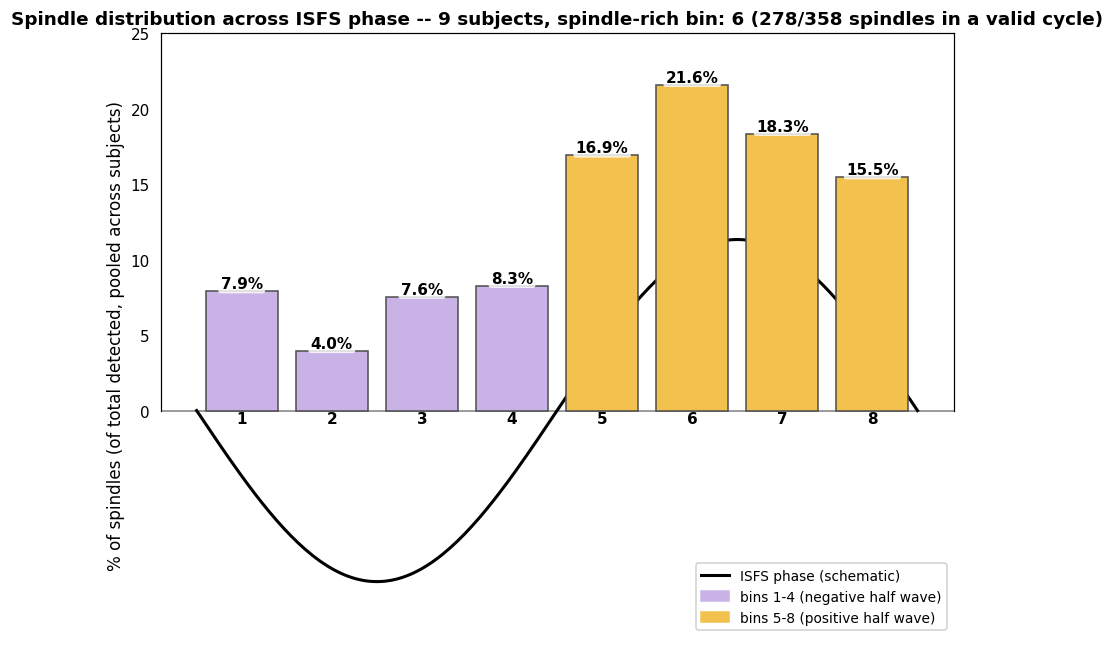

In [10]:
all_bouts_data = [bd for r in results for bd in r["bouts_data"]]
group_dist = isfs_event_phase_distribution(all_bouts_data, min_events=5) if all_bouts_data else None

if group_dist is None:
    print("Fewer than 5 pooled spindles across all subjects -- skipping group plot.")
else:
    preferred_bin_group = int(np.argmax(group_dist["pct"])) + 1

    label_bbox = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [LPURPLE if b <= 4 else GOLD for b in bin_ids]
    ax.bar(bin_ids, group_dist["pct"], color=colors, edgecolor="0.3", zorder=2)
    for b, pct in zip(bin_ids, group_dist["pct"]):
        ax.text(b, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10,
                fontweight="bold", bbox=label_bbox, zorder=6)

    ax.set(xticks=list(bin_ids), xticklabels=[""] * (len(bin_ids)))
    ax.set_ylabel("% of spindles (of total detected, pooled across subjects)", fontsize=11)
    ax.set_title(f"Spindle distribution across ISFS phase -- {len(results)} subjects, "
                 f"spindle-rich bin: {preferred_bin_group} "
                 f"({group_dist['n_in_isfs']}/{group_dist['n_total']} spindles in a valid cycle)",
                 fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=10)

    y0, y1 = ax.get_ylim()
    span = y1 - y0
    amp_curve = 0.50 * span
    x_smooth = np.linspace(0.5, N_PHASE_BINS + 0.5, 200)
    y_smooth = -amp_curve * np.sin(2 * np.pi * (x_smooth - 0.5) / N_PHASE_BINS)
    ax.plot(x_smooth, y_smooth, color="k", lw=2.0, ls="-", zorder=1, label="ISFS phase (schematic)")
    ax.axhline(0, color="0.5", lw=1.0, zorder=0)
    ax.set_ylim(min(y0, -amp_curve - 0.03 * span), max(y1, amp_curve + 0.03 * span))

    for b in bin_ids:
        ax.text(b, 0, str(b), ha="center", va="top", fontsize=10, fontweight="bold")

    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:g}" if t >= 0 else "" for t in yticks])
    ax.tick_params(axis="both", bottom=False, left=False)

    _, y1f = ax.get_ylim()
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_bounds(0, y1f)
    ax.spines["right"].set_bounds(0, y1f)

    ax.legend(handles=ax.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, label="bins 1-4 (negative half wave)"),
        Patch(color=GOLD, label="bins 5-8 (positive half wave)"),
        ],
        loc="lower right", frameon=True, framealpha=0.9, fontsize=9)
    fig.tight_layout()

    print(f"Pooled spindle-rich phase bin: {preferred_bin_group} "
          f"(center phase {bin_center_angle(preferred_bin_group):+.2f} rad, "
          f"{'trough side' if preferred_bin_group <= 4 else 'peak side'})")


## 9. Infraslow Phase vs. U-Sleep Sleep-Stage Probability (Group)


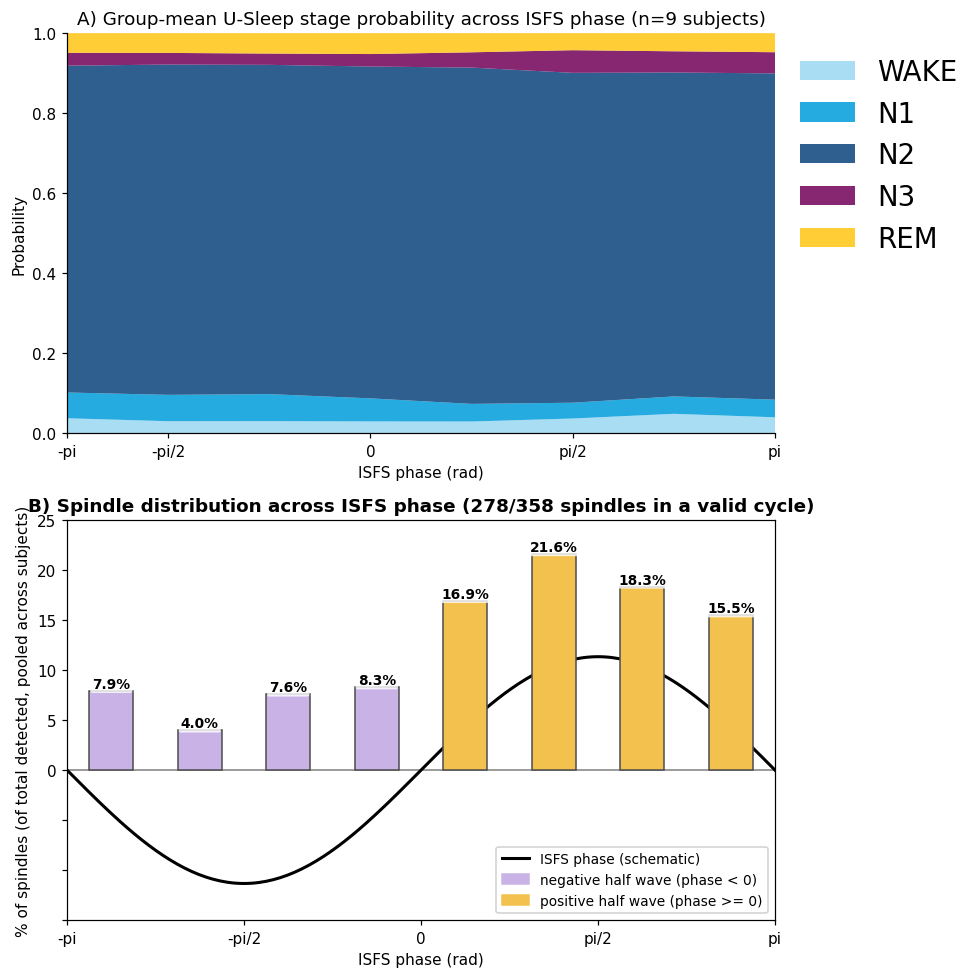

In [8]:
valid_probs = np.array([r["mean_probs_per_point"] for r in results])  # (n_subjects, N_PHASE_POINTS, 5)

phase_edges = np.linspace(-np.pi, np.pi, N_PHASE_POINTS + 1)
phase_points = (phase_edges[:-1] + phase_edges[1:]) / 2
stage_cols = [s.upper() for s in USLEEP_STAGE_ORDER]

# --- A) group-mean stacked hypnodensity vs. phase ---
proba_arr = np.nanmean(valid_probs, axis=0)
n_missing = int(np.isnan(proba_arr).any(axis=1).sum())
if n_missing:
    print(f"WARNING: {n_missing}/{N_PHASE_POINTS} phase point(s) have no in-cycle samples across "
          "the whole cohort; filling by circular linear interpolation before plotting.")
    wrapped = np.vstack([proba_arr[-5:], proba_arr, proba_arr[:5]])
    wrapped = pd.DataFrame(wrapped).interpolate(limit_direction="both").to_numpy()
    proba_arr = wrapped[5 : 5 + N_PHASE_POINTS]
proba_arr = proba_arr / proba_arr.sum(axis=1, keepdims=True)

group_labels = [stage_cols[i] for i in np.argmax(proba_arr, axis=1)]
proba_df = pd.DataFrame(proba_arr, columns=stage_cols)
hyp_phase = yasa.Hypnogram(group_labels, n_stages=5, freq="1s", proba=proba_df)

fig, (axT, axB) = plt.subplots(2, 1, figsize=(9, 9))
hyp_phase.plot_hypnodensity(ax=axT)

x_all = hyp_phase.timedelta.total_seconds() / 60
if hyp_phase.duration > 90:
    x_all = x_all / 60
tick_phases = np.array([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
tick_idx = np.array([np.argmin(np.abs(phase_points - p)) for p in tick_phases])
axT.set_xticks(x_all[tick_idx])
axT.set_xticklabels(["-pi", "-pi/2", "0", "pi/2", "pi"])
axT.set_xlabel("ISFS phase (rad)")
axT.set_title(f"A) Group-mean U-Sleep stage probability across ISFS phase (n={len(results)} subjects)")

# --- B) spindle distribution across ISFS phase
if group_dist is not None:
    label_bbox = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    bar_width = (2 * np.pi / N_PHASE_BINS) * 0.5
    bar_colors = [LPURPLE if c < 0 else GOLD for c in bin_centers]
    axB.bar(bin_centers, group_dist["pct"], width=bar_width, color=bar_colors, edgecolor="0.3", zorder=2)
    for c, pct in zip(bin_centers, group_dist["pct"]):
        axB.text(c, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9,
                  fontweight="bold", bbox=label_bbox, zorder=6)

    y0, y1 = axB.get_ylim()
    span = y1 - y0
    amp = 0.50 * span
    x_smooth = np.linspace(-np.pi, np.pi, 200)
    y_smooth = amp * np.sin(x_smooth)
    axB.plot(x_smooth, y_smooth, color="k", lw=2.0, ls="-", zorder=1, label="ISFS phase (schematic)")
    axB.axhline(0, color="0.5", lw=1.0, zorder=0)
    axB.set_ylim(min(y0, -amp - 0.03 * span), max(y1, amp + 0.03 * span))

    axB.set(xlim=(-np.pi, np.pi),
            xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
            xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
            xlabel="ISFS phase (rad)", ylabel="% of spindles (of total detected, pooled across subjects)")
    axB.set_title(f"B) Spindle distribution across ISFS phase "
                   f"({group_dist['n_in_isfs']}/{group_dist['n_total']} spindles in a valid cycle)",
                   fontsize=12, fontweight="bold")
    axB.tick_params(labelsize=10)

    yticks = axB.get_yticks()
    axB.set_yticks(yticks)
    axB.set_yticklabels([f"{t:g}" if t >= 0 else "" for t in yticks])

    axB.legend(handles=axB.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, label="negative half wave (phase < 0)"),
        Patch(color=GOLD, label="positive half wave (phase >= 0)")],
        loc="lower right", frameon=True, framealpha=0.9, fontsize=9)
else:
    axB.text(0.5, 0.5, "No spindle-phase distribution available\n(fewer than 5 pooled spindles)",
              ha="center", va="center", transform=axB.transAxes)
    axB.set_title("B) Spindle distribution across ISFS phase", fontsize=12, fontweight="bold")
    axB.set_xlim(-np.pi, np.pi)
    axB.set_xticks([])
    axB.set_yticks([])

fig.tight_layout()


## 10. Final Feature Summary (Group)


In [9]:
summary_df = pd.DataFrame([r["summary"] for r in results])
summary_df


,subject_id,channel,recording_duration_min,n2_total_duration_min,n_n2_bouts,n_spindles_total,n2_spindle_rate_per_min,mean_spindle_duration_sec,mean_spindle_amplitude_uv,mean_spindle_frequency_hz,mean_spindle_power_log10uv2,isfs_detected,isfs_peak_freq_hz,isfs_peak_period_sec,isfs_amplitude,isfs_bandwidth_hz,isfs_auc,isfs_chromatogram_peak_area,preferred_spindle_phase_bin
0,318517,C3,515.783333,8.80,2,110,2.954545,0.931773,102.910660,13.169428,2.592556,True,0.0450,22.222222,4.166034,0.019271,0.068692,0.063965,5.0
1,318562,C3,460.766667,71.55,11,239,1.677149,0.743933,51.695083,12.872424,1.997388,True,0.0450,22.222222,3.508742,0.024685,0.074108,0.054751,6.0
2,318619,C3,427.100000,49.85,9,89,0.481444,0.721629,34.909623,13.230144,1.622850,True,0.0150,66.666667,3.921815,0.075794,0.254335,0.016981,6.0
3,318658,C3,406.283333,20.05,4,46,0.249377,0.666957,44.173399,13.826857,1.884346,True,0.0175,57.142857,6.654993,0.022343,0.127222,0.035453,7.0
4,318661,C3,436.966667,20.60,4,26,0.242718,0.690192,36.362404,12.901932,1.671676,True,0.0375,26.666667,9.664504,0.026651,0.220383,0.217928,7.0
5,318667,C3,386.283333,63.70,14,103,0.737834,0.746942,43.126660,13.244449,1.758911,True,0.0250,40.000000,1.703142,0.008998,0.013112,0.016073,6.0
6,318668,C3,362.983333,20.95,4,298,4.439141,0.900654,50.247669,13.470063,2.015416,True,0.0225,44.444444,10.228266,0.062371,0.545841,0.077086,6.0
7,318679,C3,458.500000,14.70,4,302,2.585034,0.754371,53.958852,13.129214,2.069554,True,0.0150,66.666667,18.413773,0.069456,1.094289,0.058707,5.0
8,318709,C3,459.133333,7.50,1,66,0.000000,0.893636,40.825914,13.193368,1.677604,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
